In [46]:
# Here we gonna import kmeans as we will need it in step of fitting lager (splitting)
from Libraries.KMeans import *

In [ ]:
# This is unspuervised learning algorithm which means we don't have labels 
# Divisive clustering is top down view means we work from all data sets to single points
# We don't have classifcation or regression 
import numpy as np
# We need to draw some plots
import matplotlib.pyplot as plt
# We need to draw dendrogram and we can't make it from scratch as it is tideous and have dozend of matplotlib lines
from scipy.cluster.hierarchy import dendrogram

# For warnings
import warnings
warnings.filterwarnings('ignore')

class DivisiveClustering():

    # Intialization
    def __init__(self, n_clusters=2, tol=1e-4, min_cluster_size=2):
        # Here other paramerts default as API
        # We auomatic stop when 1- no split indices found 2- after indices no child found
        # We stop when we find 1- desired number of clusters 2- tol > SSE 3- the cluster size we get is lower than min threshold size
        self.n_clusters = n_clusters
        self.tol = tol
        # This has 2 functions first is get ignored from checking the best split 
        # Second is the third stopping criteria the cluster size we get is lower than min threshold size 
        # Make sure the user set it with 2 and above cause we can't make threshold less than 2 so lesser clusters will pass but kmeans can't functioning with them
        if min_cluster_size < 2 :
            min_cluster_size = 2
        self.min_cluster_size = min_cluster_size

        self.labels_ = None
        # This help us in prediction and assigning labels as prediction and assigning label is the same process as assign to the closest centroid
        self.centroids_ = None

        # Here we want to store the clusters as list of indices
        # So it is list of lists
        self.indices = []

    # Helper functions
    # SSE function
    def sse(self, X_cluster):
        # We work with real data not indices
        if len(X_cluster) <= 1:
            # We won't find sse with one point or zero so SSE it gonna be zero
            return 0.0
        
        # Get centroid of cluster
        # Convert from 2D matrix (m, n) to 1D matrix (mmean,) 
        centroid  = np.mean(X_cluster, axis = 0)

        # SSE = sum of squared distances from all points to their mean (centroid)
        sse = np.sum((X_cluster - centroid) **2)
        return sse

    # Find the best split and it is the most important function
    def _find_best_split(self):
        # The function has no argument as it loops over indices which is global and change every iteration of algorithm itself
        # Intialize best indices and best SSE of target cluster as we chaoose the highest SSE to get split
        # Here the target is the worst cluster ever which has the most dispresion which is the highest SSE
        best_pos = None
        best_sse = -np.inf

        # Loop ove current existing clusters
        # self.indices stores all current clusters
        # And each cluster is a list (collection of indices or indexes) and each cluster iteration we gave it number as the index of cluster
        # So (i) is the index of list (cluster) and idxs are the inner indexes of the list itself (cluster)
        # We need both of them so i clarify which position (pos) of the best cluster to split and return its SSE
        # Loop over clusters 
        for i, idxs in enumerate(self.indices):
            # Ignore all small clusters from check
            # Any lenght of cluster less than min_clauster_size
            if len(idxs) < self.min_cluster_size:
                continue

            # Caluclate SSE for current cluster then later choose the highest
            # Here i send real data not just indices
            # Don't worry each indice has unique number and never change between X or whatever
            current_sse = self.sse(self.X[idxs])
            
            # Invistigate SSE per iteration and compare it with the best to get final best
            if current_sse > best_sse:
                # Update the best SSE
                best_sse = current_sse 
                # Get the index of the cluster so it gonna be target
                best_pos = i

        # Return both the index of the cluster with its SSE
        return best_pos, best_sse    
            
    # Silhouette function
    def _calculate_silhouette(self, X):
        # Get samples number
        n_samples = X.shape[0]

        # Get all scores cause later we get the mean
        silhouette_vals = []
        
        if len(np.unique(self.labels_)) < 2:
            # We make the indicator her to be labels itself so we avoid over numbers of clusters when we stop
            return 0.0
        
        # loop over all points and inside each iteration we have another loop for the closest cluster
        for i in range(n_samples):
            # Get a(i) so we work in the same cluster
            # Get the cluster of point first
            inside_cluster = X[self.labels_ == self.labels_[i]]
            if len(inside_cluster) > 1:
                # Make sure it is has more than two points
                # Inside cluster is the current cluster points
                a = np.mean(np.linalg.norm(inside_cluster - X[i], axis=1))
            else:
                # No points so no averga
                a = 0

            # intialize b to get min b at the end 
            b = np.inf
            # Loop over other clusters and we guarantee that is the real number of clusters
            for label in np.unique(self.labels_):
                # Get b(i) so we work with the closets cluster ignoring our current one
                if label == self.labels_[i]:
                    continue
                
                # Each time we calcualte b till we get the min one
                # Outside cluster is the outer current cluster points
                outside_cluster = X[self.labels_ == label]
                
                if len(outside_cluster)>0:
                    # Make sure it has point
                    current_b = np.mean(np.linalg.norm(outside_cluster - X[i], axis=1))
                    b = min(b, current_b)
            
            # Calcualte silhouette for current point and to be added later to the silhouette_vals
            # Add stability term to avoid zero devsion
            s = (b - a)  / (max(a, b) + 1e-9)       
            silhouette_vals.append(s)

        # Get the average of all score
        return np.mean(silhouette_vals)    

    # Fit
    def fit_predict(self, X):
        # Convert x to array
        X = np.array(X) 
        self.X = X
        # get samples number
        n_samples = X.shape[0]

        # Step 0 --> start with all points in one cluster
        # We work with indexing as it is the fastest
        # We work with real data in two events 1- get SSE 2- get kmeans
        # We range from 0 as default to the number of samples and store them in list
        # Len(samples) = indices number
        # Indices themselves are list from 0 to the lenght of the samples (indices number)
        self.indices = [list(range(n_samples))]

        # Step 3 --> after update clusters we loop again till one of the 5 stopping criterias triggered
        # This is the first stopping criteria when we are above the desired number of clusters
        while len(self.indices) < self.n_clusters:
            # As long as we are less than desired number of clusters
            # Step 1 --> choose the best split based on highest SSE
            # Later we called the best_pos to be to_split: the index of the cluster (list) supposed to splt from self.indices
            # Max_sse which is the best SSE
            to_split, max_sse = self._find_best_split()

            # If to_split is none that means no split cluster found
            # Means all cluster are too small and never skip the conditon of if len(idxs) < self.min_cluster_size: continue 
            # This is the automatic stopping criteria 
            if to_split is None:
                break

            # This is the second stopping criteria Stop if SSE is less than tol then that means no improvement
            if max_sse < self.tol:
                break        

            # Apply kmeans with deafult n_clusters = 2 on the choosen cluster 
            # K = 2 it is the best choice so that at first iteration we make it to only 2 childs and so on
            # Here we split not seperation
            # Get choosen cluster based on best_po 
            # Till now we work with indices (indexes)
            target = self.indices[to_split]

            # This is the third stopping criteria Stop if the target cluster is too small to split
            # Why 2 is min of min_cluster_size ? because kmeans needs at least two points to split and we handle it from begging to be 2 or more
            if len(target) < self.min_cluster_size:
                break

            # Apply k means with k = 2
            # We use here real data
            X_k = self.X[target]
            # It is mandatory the clusters to be 2 but the threshold points number is 2 and above
            km = Kmeans(n_clusters=2)
            # Be careful it gonna return objects not labels
            km.fit_predict(X_k)
            # We need to return labels
            # Access returned labels through self.labels_
            k_labels = km.labels_
           
            # So we have two labels cluster = 0 and cluster = 1 form K _labels
            # Be careful assigning labels not from here i just use kmeans to split one cluster to 2 children clusters
            # Labels come up later like agglomerative
            # Build child clusters as lists then add them later to the updated indices
            # Build cluster 0
            cluster_0 = [target[i] for i in range(len(target)) if k_labels[i] == 0]
            # Build cluster 1
            cluster_1 = [target[i] for i in range(len(target)) if k_labels[i] == 1]

            # This is the automatic stopping criteria when one split is empty
            if len(cluster_0) == 0 or len(cluster_1) == 0:
                break

            # Step 3 --> update current indices list 
            # Replace the target cluster with its children
            # We work with indices which are similar numbers to index
            # Remove the target indices
            self.indices.pop(to_split)
            # Replace with the children
            self.indices.append(cluster_0)
            self.indices.append(cluster_1)

        # Step 4 --> Assigning labels and centroids after one stopping criteria interrupted the splitting flow
        # Assigning labels is important for fitting and centroids for prediction
        # Intialize matrices of labels and centroids
        # Final labels
        # Create label indices = n_samples because labels number is the number of samples
        self.labels_ = np.zeros(n_samples, dtype=int)
        # Final centroids
        # create cetroids indices = len(self.indices) because centroids number is the number of clusters (lists) inside the greater list (self.indices)
        self.centroids_ = np.zeros((len(self.indices), self.X.shape[1]))

        # Assigning is the same as agglomerative   
        # And each cluster is a list (collection of indices or indexes) and each cluster iteration we gave it number as the index of cluster (cluster label)
        # So (cluster_label) is the index of list (cluster) and idxs are the inner indexes of the list itself (cluster)
        # We need both of them so i clarify which cluster label for labels_ and also use idxs for generating centroids
        for cluster_label, idxs in enumerate(self.indices):
                # Cluster _label --> 0, 1, 2 and idxs is the indexes in each 
                # Assign labels to each cluster (0, 1, 2 etc)
                # Labels (m,)
                # Filter label indices with idxs indices
                self.labels_[idxs] = cluster_label
                # Add centroids for later prediction
                # Cenroids added per cluster_label and its lenght = number of lists in the greated list (self.indices) (clusters)
                # Filter cetroid indices with clsuter_label indices so at 0 centoid all data related to x[idxs] for cluster 0 and so on    
                # Convert from 2D matrix (m, n) to to get mean of columns to be (m, nmeans)
                # Centroids (num_of_clusters, n)
                # Don't forget centroids are the mean so we devide sum(feature for all observations) / n_samples
                self.centroids_[cluster_label] = np.mean(self.X[idxs], axis=0)     
               
        # Silhouette case always
        self.silhouette_ = self._calculate_silhouette(X)
        return self

    # Predict
    def predict(self, X_test):
        # The same as agglomerative
        # Here it is just geaometric prediction
        # Convert X_test to array
        X_test = np.array(X_test)
        # Return predictions
        preds = []
        for x in X_test:
            # Here we assign cluster based on the standard method which is geometric assignment (centroids based)
            # Get all distances with points 
            # Index represents sample and column represents differ
            # Cetroids are (m, n) and x is (,n) result will be (mdiffer, n)
            # Get norm from axis = 1 which norm of each feature difference
            # dist is 1D matrix (mdist,)
            # Here we got number of distances 
            dists = np.linalg.norm(self.centroids_ - x, axis=1)
            # We don't need labels_ matrix as it is for fit_predict for first time
            # We got the min distance index which is number of centroid which is label itself 
            # As centroid 0 equivelant to label 0 and so on
            # Assign label of nearest distance and assign its labal
            preds.append(self.labels_[np.argmin(dists)])
        return np.array(preds)      

Calculating Elbow Method...


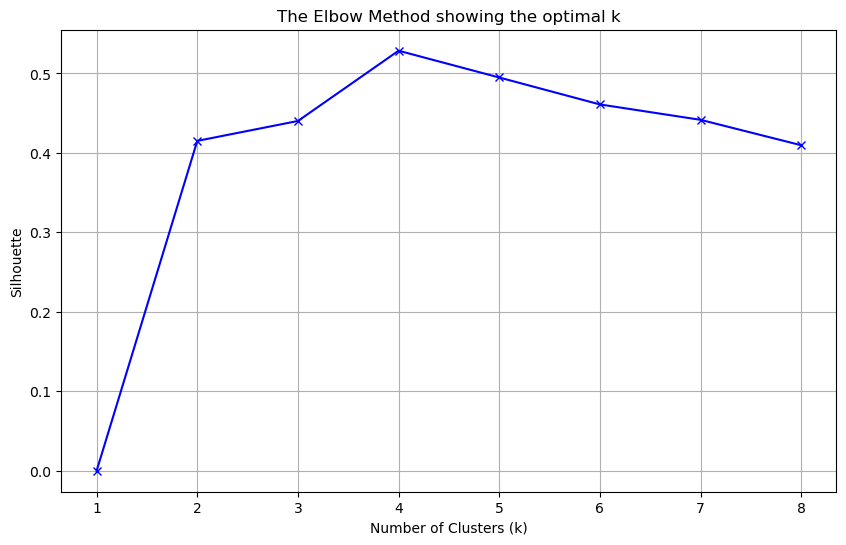

In [48]:
# For plotting purposes
import matplotlib.pyplot as plt

# Sample data
# Create number of rows and random x and y matrices
m = 100
# Use rand then multiple by 2 to make sure the samples values are between 0 and 2 this would make sure we simulate feature scaling
# Here we create 2 features
X1 = 2 * np.random.rand(m, 1)
X2 = 2 * np.random.rand(m, 1)
# Combine features to create X matrix
# We work only with x as y (label not exist)
X = np.column_stack((X1, X2))

# Test data with 2 rows
X_new = np.array([[1,2], [3,4], [4,3]])

# Get the best K using Elblow method
print("Calculating Elbow Method...")

K = 9

silhouette_scores = []
for cluster_no in range(1, K):
    # Get Divisive Clustering object
    model = DivisiveClustering(n_clusters=cluster_no)
    model.fit_predict(X)
    silhouette_scores.append(model.silhouette_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, K), silhouette_scores, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()

In [49]:
# k = 4 and average method are the best silheutte score 
k = 4

print(f'Model:Divisive')
# Get Agglomerative Clustering object
div_model = DivisiveClustering(n_clusters=k)
div_model.fit_predict(X)
pred = div_model.predict(X_new)
print(f'Predictions for {X_new.tolist()}: {pred}')
print(f'Evaluation score: {div_model.silhouette_:.2f}')
print(f'Labels: \n{np.unique(div_model.labels_)}')
print(f'Centroids: \n{div_model.centroids_}')
print('-'*40)

Model:Divisive
Predictions for [[1, 2], [3, 4], [4, 3]]: [2 2 2]
Evaluation score: 0.53
Labels: 
[0 1 2 3]
Centroids: 
[[0.30374999 1.62248047]
 [0.58486197 0.49796923]
 [1.57523528 1.46222827]
 [1.63921722 0.38805125]]
----------------------------------------
